# Lab 8 - Decision Trees: Classification & Regression
- **Task 1:** Play Tennis Decision Tree
- **Task 2:** Iris Flower with GridSearchCV
- **Task 3:** Titanic Survival Classification
- **Task 4:** House Prices Regression Tree

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import (accuracy_score, precision_score, recall_score,classification_report, confusion_matrix, mean_squared_error, r2_score)
from sklearn.preprocessing import LabelEncoder

---
## Task 1: Play Tennis - Decision Tree Classifier

### Load the Play Tennis Dataset

In [2]:
df_tennis = pd.read_csv('tennis.csv')
print(f'Shape: {df_tennis.shape}')
df_tennis

Shape: (14, 5)


,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


### Encode Categorical Features

In [3]:
le_dict = {}
df_tennis_encoded = df_tennis.copy()
for col in df_tennis.columns:
    le = LabelEncoder()
    df_tennis_encoded[col] = le.fit_transform(df_tennis[col])
    le_dict[col] = le

df_tennis_encoded

,outlook,temp,humidity,windy,play
0,2,1,0,0,0
1,2,1,0,1,0
2,0,1,0,0,1
3,1,2,0,0,1
4,1,0,1,0,1
5,1,0,1,1,0
6,0,0,1,1,1
7,2,2,0,0,0
8,2,0,1,0,1
9,1,2,1,0,1


### Build Decision Tree Classifier

In [34]:
X_tennis = df_tennis_encoded.drop('play', axis=1)
y_tennis = df_tennis_encoded['play']

# split data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_tennis, y_tennis, test_size=0.2, random_state=42)

dt_tennis = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_tennis.fit(X_train, y_train)

print(f'Training Accuracy: {accuracy_score(y_train, dt_tennis.predict(X_train)) * 100:.2f}%')


# predict on test set
y_pred = dt_tennis.predict(X_test)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le_dict['play'].classes_))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Training Accuracy: 100.00%
Test Accuracy: 100.00%
Classification Report:
              precision    recall  f1-score   support

          no       1.00      1.00      1.00         1
         yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix:
[[1 0]
 [0 2]]


### Visualize the Decision Tree

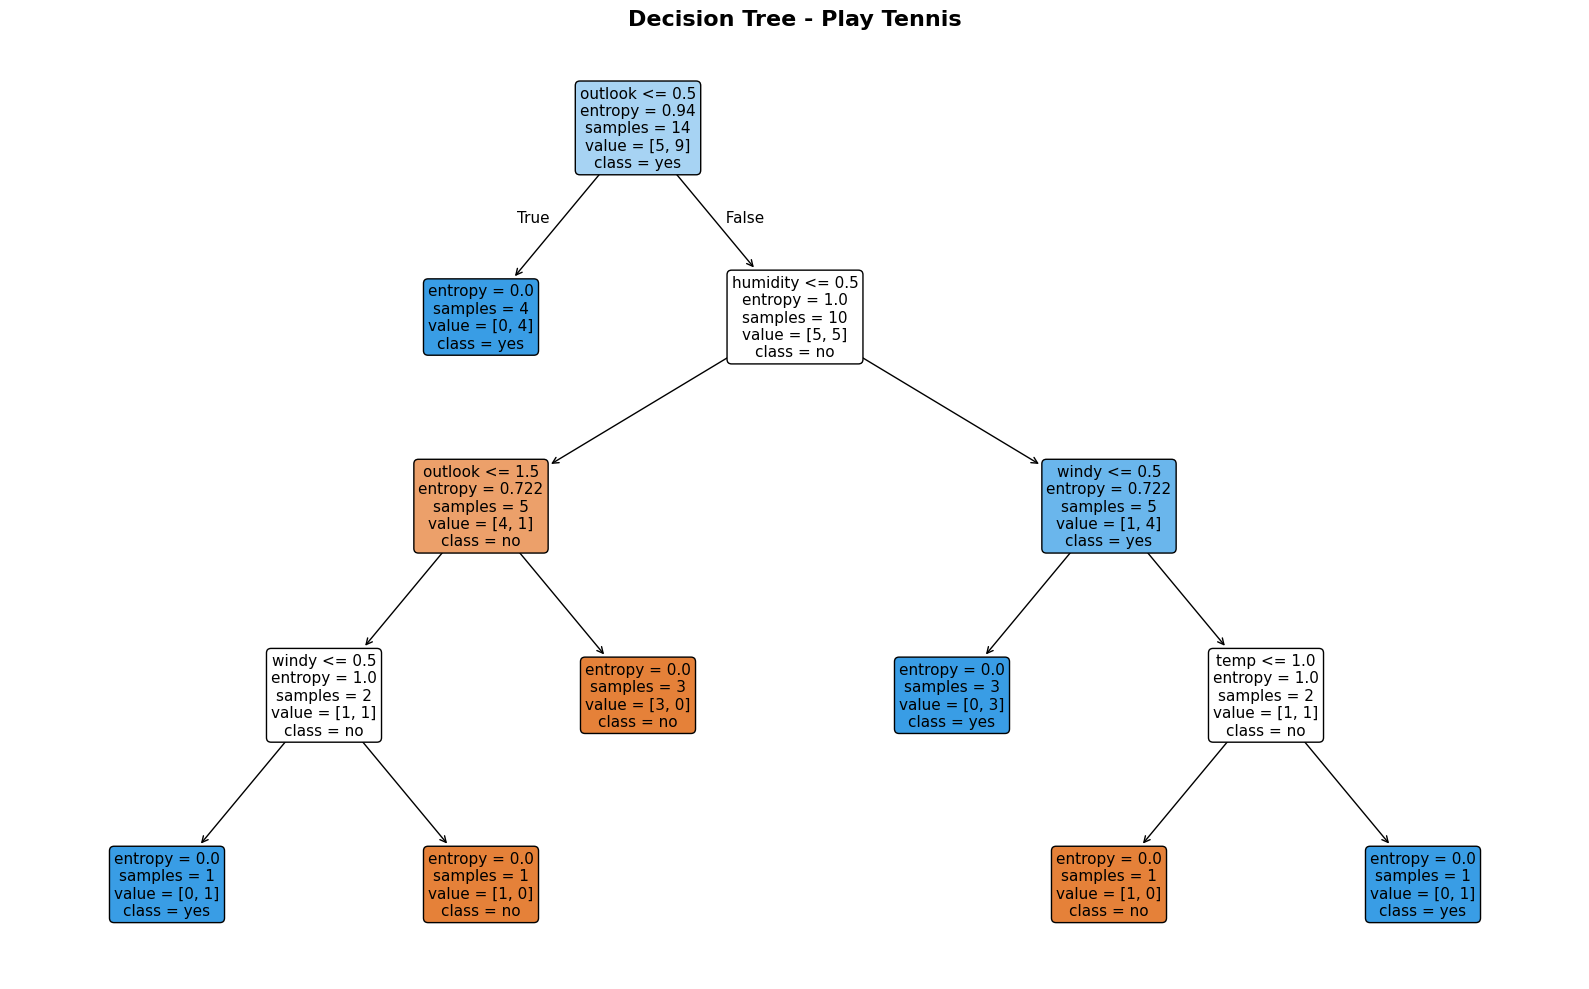

In [5]:
plt.figure(figsize=(16, 10))
plot_tree(dt_tennis,
          feature_names=['outlook', 'temp', 'humidity', 'windy'],
          class_names=le_dict['play'].classes_,
          filled=True, rounded=True, fontsize=11)
plt.title('Decision Tree - Play Tennis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Print Tree Rules

In [6]:
print(export_text(dt_tennis, feature_names=['outlook', 'temp', 'humidity', 'windy']))

|--- outlook <= 0.50
|   |--- class: 1
|--- outlook >  0.50
|   |--- humidity <= 0.50
|   |   |--- outlook <= 1.50
|   |   |   |--- windy <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- windy >  0.50
|   |   |   |   |--- class: 0
|   |   |--- outlook >  1.50
|   |   |   |--- class: 0
|   |--- humidity >  0.50
|   |   |--- windy <= 0.50
|   |   |   |--- class: 1
|   |   |--- windy >  0.50
|   |   |   |--- temp <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- temp >  1.00
|   |   |   |   |--- class: 1



### Predict PlayTennis for New Sample

In [35]:
new_sample = pd.DataFrame({'outlook': ['sunny'], 'temp': ['cool'], 'humidity': ['normal'], 'windy': ['false']})
print(f'Input: {new_sample.to_dict("records")[0]}')

new_encoded = new_sample.copy()
for col in new_sample.columns:
    new_encoded[col] = le_dict[col].transform(new_sample[col])

prediction = dt_tennis.predict(new_encoded)
pred_label = le_dict['play'].inverse_transform(prediction)
print(f'Prediction: play = {pred_label[0]}')

Input: {'outlook': 'sunny', 'temp': 'cool', 'humidity': 'normal', 'windy': 'false'}
Prediction: play = yes


---
## Task 2: Iris Flower - GridSearchCV Classification

### Load the Iris Dataset

In [37]:
df_iris = pd.read_csv('Iris.csv')
print(f'Shape: {df_iris.shape}')
print(f'\nSpecies Distribution:\n{df_iris["Species"].value_counts()}')
df_iris.head()

Shape: (150, 6)

Species Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Prepare Features and Split Data

In [9]:
X_iris = df_iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y_iris = df_iris['Species']

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

print(f'Training set: {X_train_iris.shape[0]} samples')
print(f'Testing set:  {X_test_iris.shape[0]} samples')

Training set: 120 samples
Testing set:  30 samples


### GridSearchCV for Best Hyperparameters

In [39]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_iris = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt_iris, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_iris, y_train_iris)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV Accuracy: {grid_search.best_score_ * 100:.2f}%')

Best Parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 94.17%


### Evaluate on Test Set

In [40]:
best_dt_iris = grid_search.best_estimator_
y_pred_iris = best_dt_iris.predict(X_test_iris)

print(f'Test Accuracy: {accuracy_score(y_test_iris, y_pred_iris) * 100:.2f}%')
print(f'\nClassification Report:')
print(classification_report(y_test_iris, y_pred_iris))

Test Accuracy: 93.33%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



### Visualize the Best Decision Tree

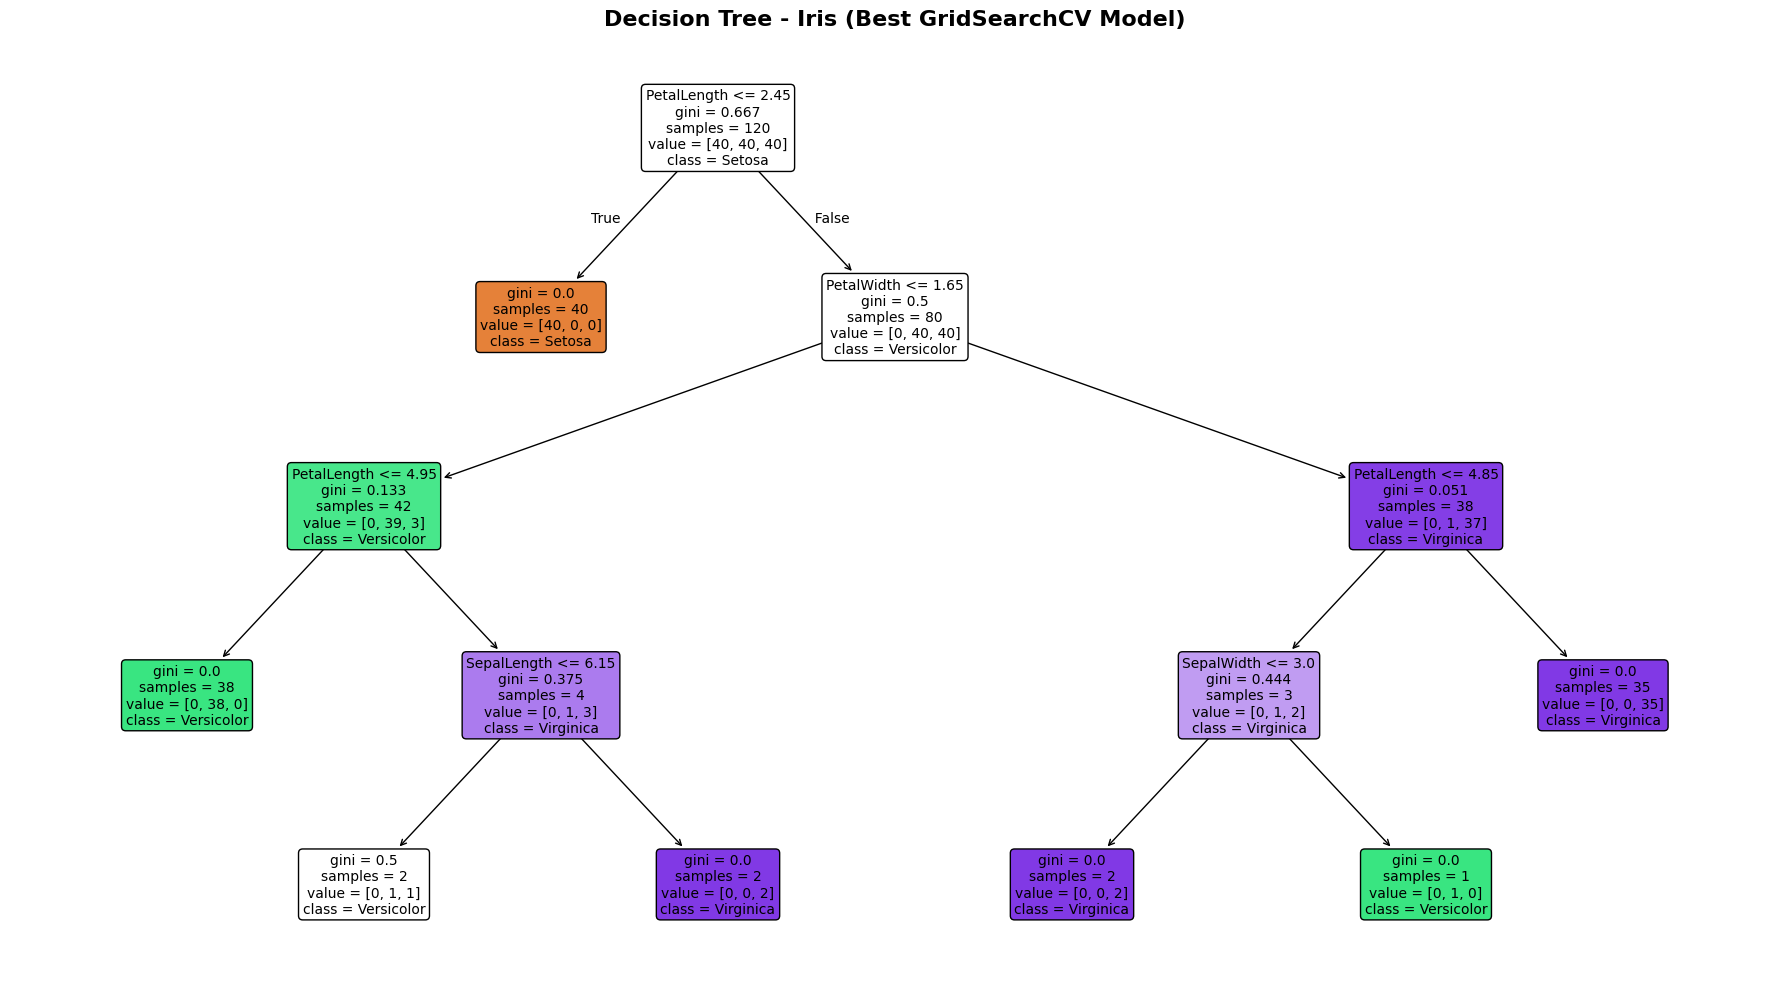

In [41]:
plt.figure(figsize=(18, 10))
plot_tree(best_dt_iris,
          feature_names=['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth'],
          class_names=['Setosa', 'Versicolor', 'Virginica'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree - Iris (Best GridSearchCV Model)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Confusion Matrix

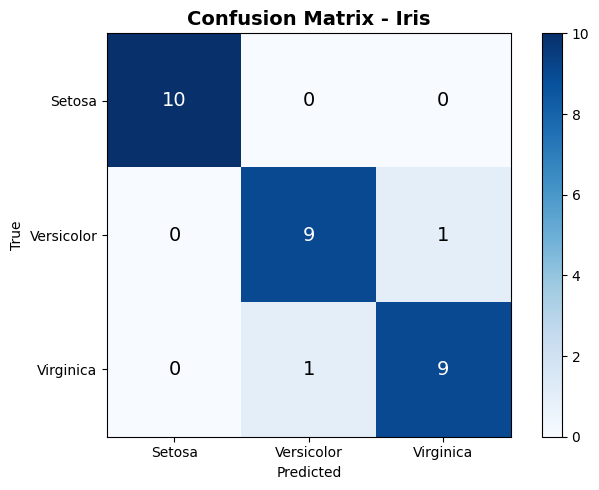

In [13]:
cm_iris = confusion_matrix(y_test_iris, y_pred_iris)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm_iris, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion Matrix - Iris', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax)
classes = ['Setosa', 'Versicolor', 'Virginica']
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(classes); ax.set_yticklabels(classes)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm_iris[i, j]), ha='center', va='center',
                color='white' if cm_iris[i, j] > cm_iris.max()/2 else 'black', fontsize=14)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.show()

---
## Task 3: Titanic - Survival Classification

### Load the Titanic Dataset

In [21]:
df_titanic = pd.read_csv('Titanic-Dataset.csv')
print(f'Shape: {df_titanic.shape}')
print(f'\nSurvived Distribution:\n{df_titanic["Survived"].value_counts()}')
df_titanic.head()

Shape: (891, 12)

Survived Distribution:
Survived
0    549
1    342
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Check Missing Values

In [22]:
print('Missing Values BEFORE handling:')
missing = df_titanic.isnull().sum()
print(missing[missing > 0])

Missing Values BEFORE handling:
Age         177
Cabin       687
Embarked      2
dtype: int64


### Handle Missing Values

In [23]:
# Age: fill with median
df_titanic['Age'].fillna(df_titanic['Age'].median(), inplace=True)

# Embarked: fill with mode
df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0], inplace=True)

# Cabin: too many missing values, drop it
df_titanic.drop('Cabin', axis=1, inplace=True)

print('Missing Values AFTER handling:')
missing_after = df_titanic.isnull().sum()
print(missing_after[missing_after > 0] if missing_after.sum() > 0 else 'None!')

Missing Values AFTER handling:
Age         177
Embarked      2
dtype: int64


C:\Users\alikh\AppData\Local\Temp\ipykernel_22488\3587348733.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_titanic['Age'].fillna(df_titanic['Age'].median(), inplace=True)
C:\Users\alikh\AppData\Local\Temp\ipykernel_22488\3587348733.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through 

### Feature Engineering & Data Splitting

In [24]:
# Encode Sex and Embarked
df_titanic['Sex'] = df_titanic['Sex'].map({'male': 0, 'female': 1})
le_embarked = LabelEncoder()
df_titanic['Embarked'] = le_embarked.fit_transform(df_titanic['Embarked'])

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X_titanic = df_titanic[features]
y_titanic = df_titanic['Survived']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42, stratify=y_titanic)

print(f'Training set: {X_train_t.shape[0]} samples')
print(f'Testing set:  {X_test_t.shape[0]} samples')

Training set: 712 samples
Testing set:  179 samples


### Build Decision Tree & Predict

In [25]:
dt_titanic = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_titanic.fit(X_train_t, y_train_t)
y_pred_t = dt_titanic.predict(X_test_t)

### Evaluate: Accuracy, Precision, and Recall

In [26]:
accuracy_t = accuracy_score(y_test_t, y_pred_t)
precision_t = precision_score(y_test_t, y_pred_t)
recall_t = recall_score(y_test_t, y_pred_t)

print(f'Accuracy:  {accuracy_t * 100:.2f}%')
print(f'Precision: {precision_t * 100:.2f}%')
print(f'Recall:    {recall_t * 100:.2f}%')
print(f'\nClassification Report:')
print(classification_report(y_test_t, y_pred_t, target_names=['Not Survived', 'Survived']))

Accuracy:  77.09%
Precision: 71.88%
Recall:    66.67%

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.80      0.84      0.82       110
    Survived       0.72      0.67      0.69        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179



### Confusion Matrix

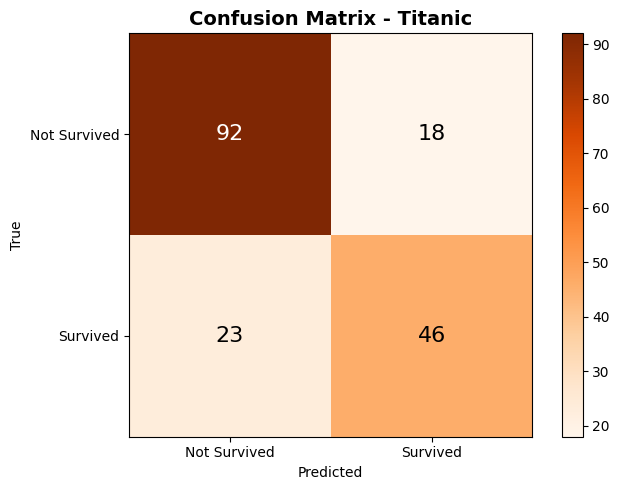

In [27]:
cm_t = confusion_matrix(y_test_t, y_pred_t)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm_t, interpolation='nearest', cmap='Oranges')
ax.set_title('Confusion Matrix - Titanic', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax)
cls = ['Not Survived', 'Survived']
ax.set_xticks(range(2)); ax.set_yticks(range(2))
ax.set_xticklabels(cls); ax.set_yticklabels(cls)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_t[i, j]), ha='center', va='center',
                color='white' if cm_t[i, j] > cm_t.max()/2 else 'black', fontsize=16)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.show()

### Feature Importance

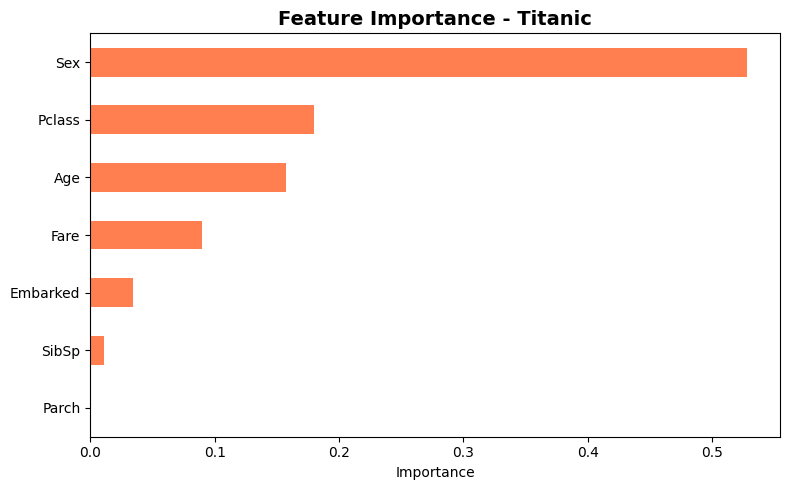

In [28]:
feat_imp = pd.Series(dt_titanic.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='coral')
plt.title('Feature Importance - Titanic', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

---
## Task 4: House Prices - Regression Tree

### Load the Housing Dataset

In [31]:
df_housing = pd.read_csv('housing.csv')
print(f'Shape: {df_housing.shape}')
df_housing.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Handle Missing Values & Encode Features

In [32]:
print('Missing Values:')
missing_h = df_housing.isnull().sum()
print(missing_h[missing_h > 0])

df_housing['total_bedrooms'].fillna(df_housing['total_bedrooms'].median(), inplace=True)

le_ocean = LabelEncoder()
df_housing['ocean_proximity'] = le_ocean.fit_transform(df_housing['ocean_proximity'])
print('\nMissing values handled and ocean_proximity encoded.')

Missing Values:
total_bedrooms    207
dtype: int64

Missing values handled and ocean_proximity encoded.


C:\Users\alikh\AppData\Local\Temp\ipykernel_22488\1886961078.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_housing['total_bedrooms'].fillna(df_housing['total_bedrooms'].median(), inplace=True)


### Prepare Features & Split Data

In [33]:
X_housing = df_housing.drop('median_house_value', axis=1)
y_housing = df_housing['median_house_value']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42)

print(f'Training set: {X_train_h.shape[0]} samples')
print(f'Testing set:  {X_test_h.shape[0]} samples')

Training set: 16512 samples
Testing set:  4128 samples


### Build Regression Tree & Predict

In [25]:
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train_h, y_train_h)
y_pred_h = dt_reg.predict(X_test_h)

### Evaluate: MSE and R² Score

In [26]:
mse = mean_squared_error(y_test_h, y_pred_h)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_h, y_pred_h)

print(f'Mean Squared Error (MSE):  {mse:,.2f}')
print(f'Root MSE (RMSE):           {rmse:,.2f}')
print(f'R² Score:                  {r2:.4f}')

Mean Squared Error (MSE):  5,023,863,776.53
Root MSE (RMSE):           70,879.22
R² Score:                  0.6166


### Visualize the Regression Tree

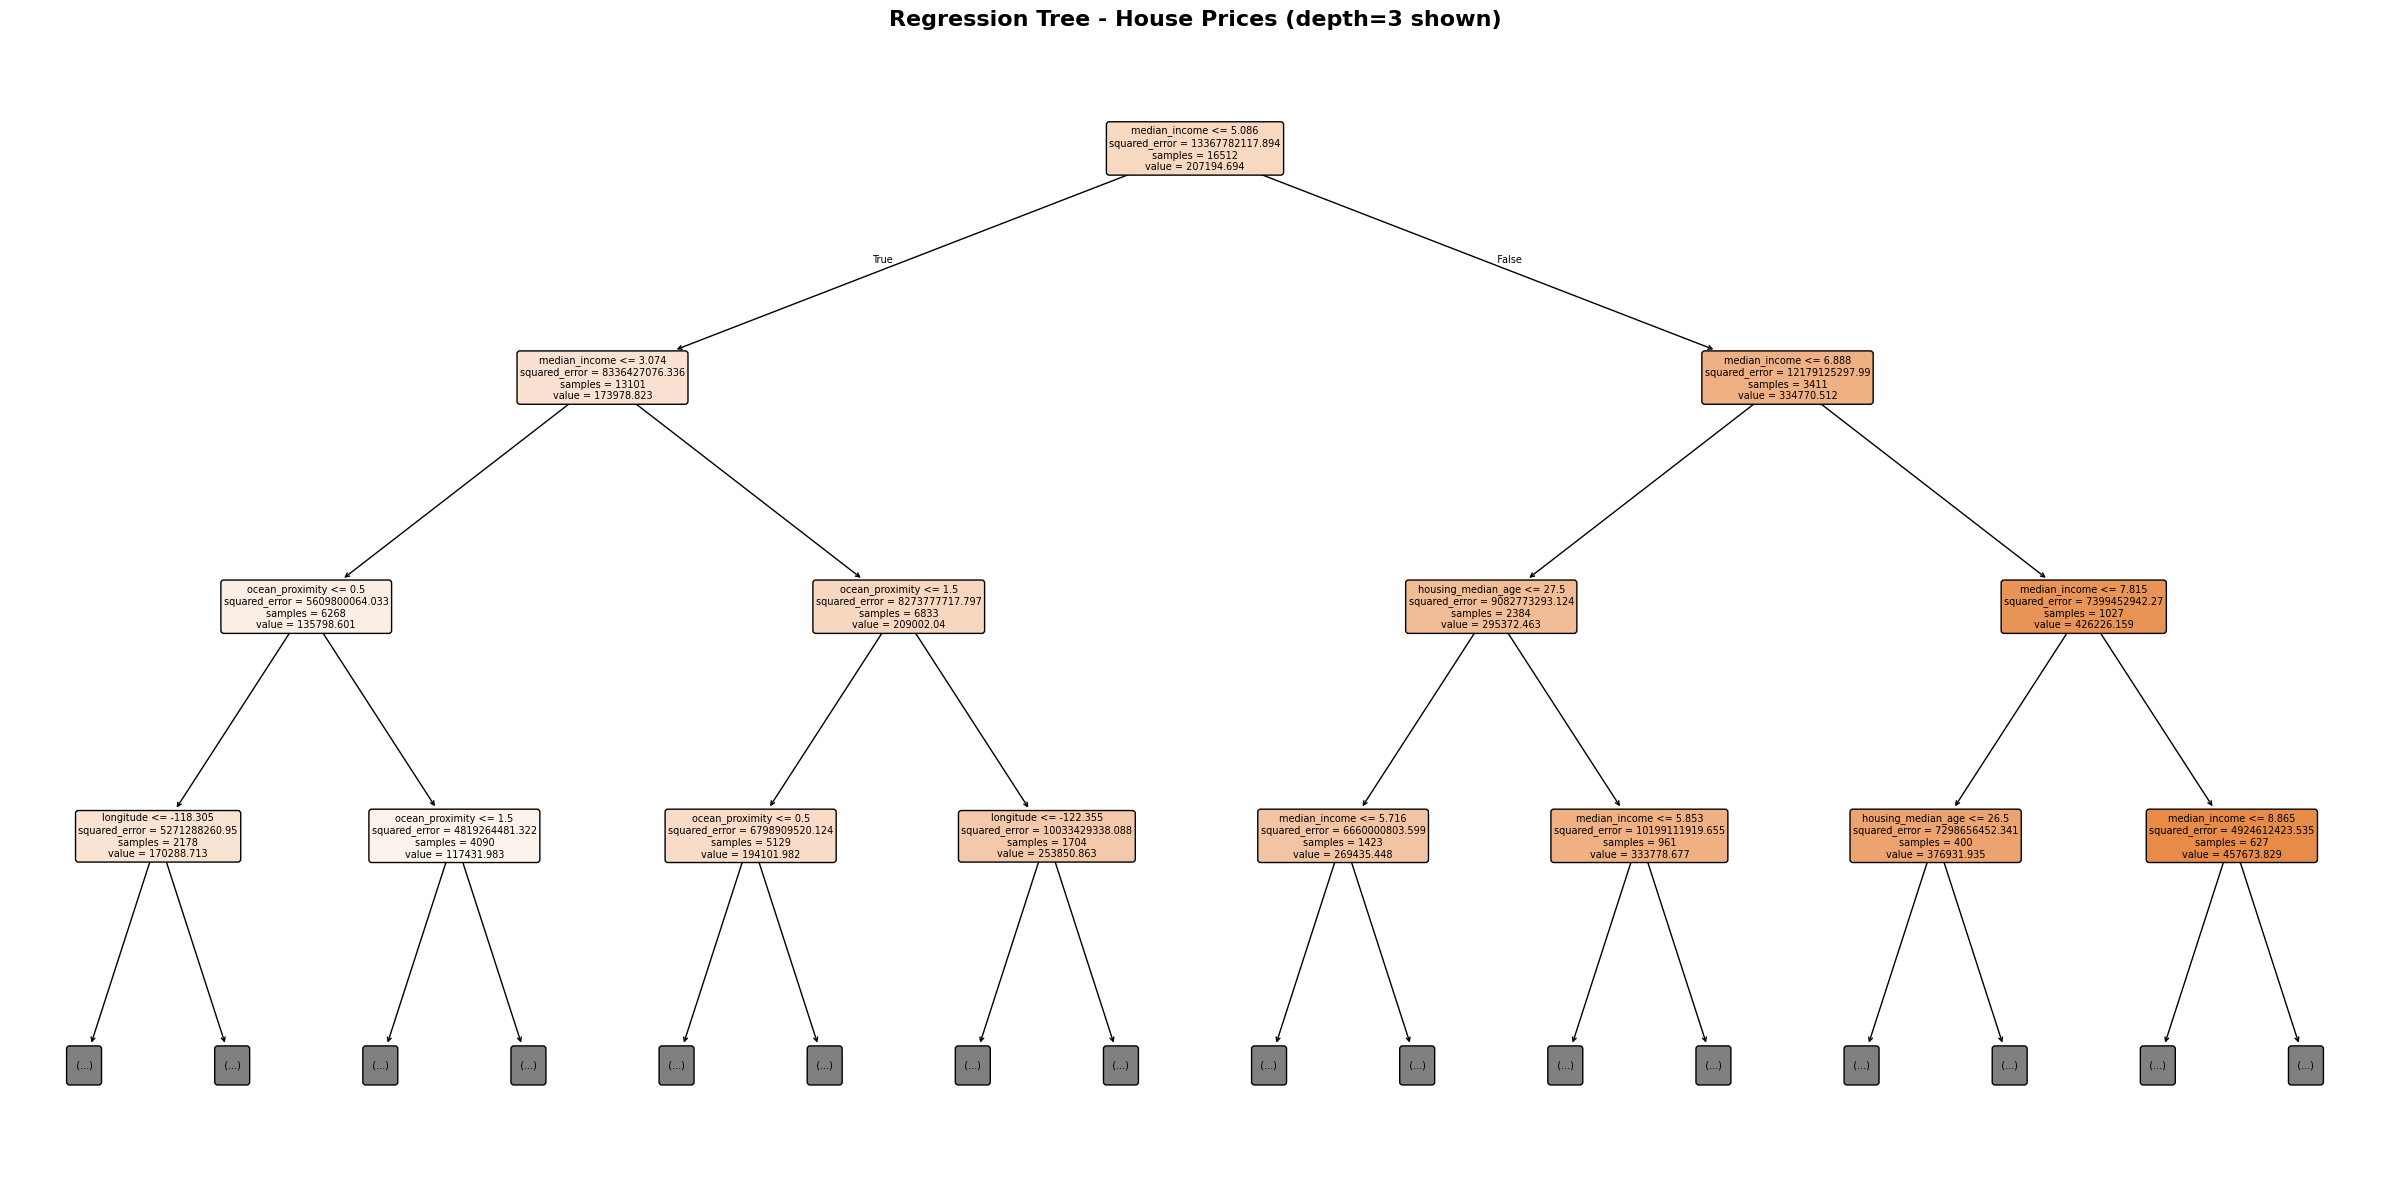

In [27]:
plt.figure(figsize=(24, 12))
plot_tree(dt_reg, feature_names=X_housing.columns.tolist(),
          filled=True, rounded=True, fontsize=7, max_depth=3)
plt.title('Regression Tree - House Prices (depth=3 shown)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Actual vs Predicted Plot

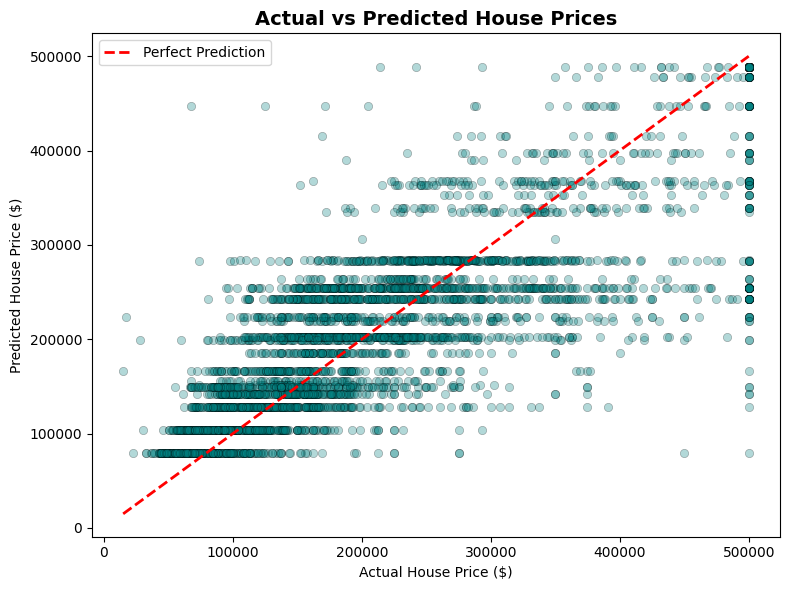

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_h, y_pred_h, alpha=0.3, color='teal', edgecolors='black', linewidths=0.5)
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual House Price ($)')
plt.ylabel('Predicted House Price ($)')
plt.title('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance

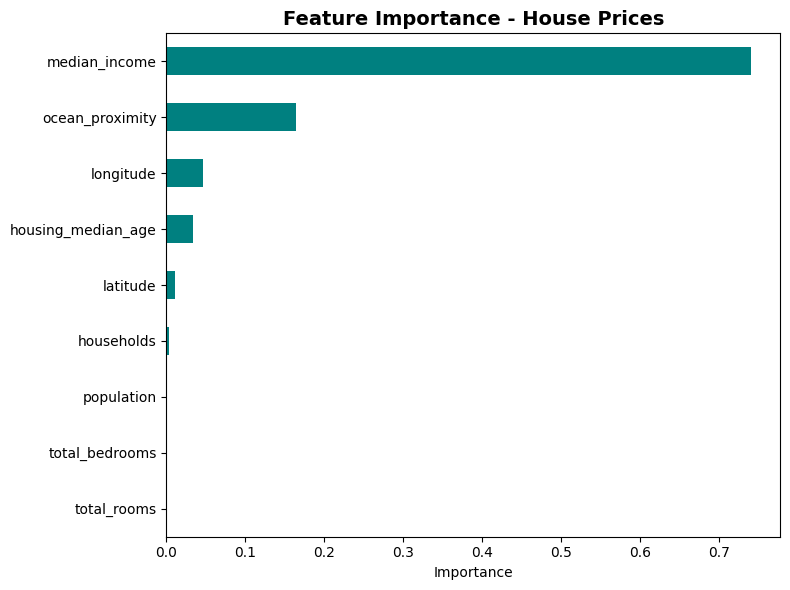

In [29]:
feat_imp_h = pd.Series(dt_reg.feature_importances_, index=X_housing.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
feat_imp_h.plot(kind='barh', color='teal')
plt.title('Feature Importance - House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()